In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [27]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root","num_file_creations",
"num_shells","num_access_files","num_outbound_cmds","is_host_login",
"is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
"rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
"srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate",
"attack","difficulty"
]

train_data = pd.read_csv("KDDTrain+.txt", names=columns)
test_data = pd.read_csv("KDDTest+.txt", names=columns)

train_data = train_data.drop("difficulty", axis=1)
test_data = test_data.drop("difficulty", axis=1)

print("Dataset loaded.")
print(train_data.shape)



Dataset loaded.
(125973, 42)


In [28]:
dos_attacks = ["neptune","smurf","pod","teardrop","land","back"]
probe_attacks = ["satan","ipsweep","nmap","portsweep","mscan","saint"]

def map_attack(attack):
    if attack == "normal":
        return 0
    elif attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    else:
        return 3

train_data["attack_type"] = train_data["attack"].apply(map_attack)
test_data["attack_type"] = test_data["attack"].apply(map_attack)

train_data = train_data.drop("attack", axis=1)
test_data = test_data.drop("attack", axis=1)

print("Attack categories mapped.")





Attack categories mapped.


In [29]:
categorical_cols = ["protocol_type","service","flag"]

train_data = pd.get_dummies(train_data, columns=categorical_cols)
test_data = pd.get_dummies(test_data, columns=categorical_cols)

train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

print("Categorical features encoded.")



Categorical features encoded.


In [30]:
X_train = train_data.drop("attack_type", axis=1)
y_train = train_data["attack_type"]

X_test = test_data.drop("attack_type", axis=1)
y_test = test_data["attack_type"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, predictions))




Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.97      0.78      9711
           1       0.94      0.97      0.95      5741
           2       0.82      0.59      0.69      2421
           3       0.99      0.03      0.06      4671

    accuracy                           0.74     22544
   macro avg       0.85      0.64      0.62     22544
weighted avg       0.81      0.74      0.66     22544



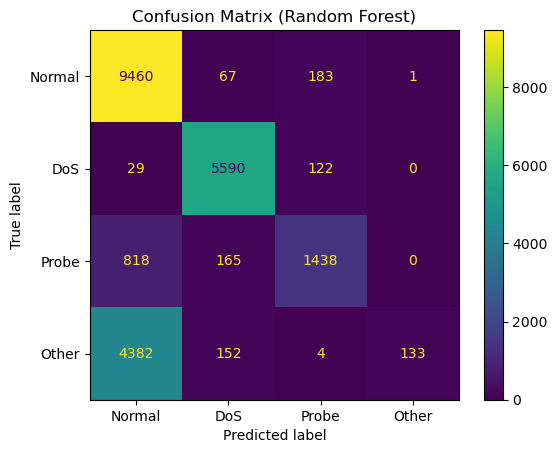

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "DoS", "Probe", "Other"]
)

disp.plot()
plt.title("Confusion Matrix (Random Forest)")
plt.show()

In [32]:
Q = np.zeros((4, 4))

alpha = 0.1
gamma = 0.9

epsilon = 1.0   

episodes = 3000

total_rewards = []
epsilon_values = []


In [33]:
def get_reward(true_label, action):

    # Actions:
    # 0 = allow
    # 1 = block
    # 2 = throttle
    # 3 = alert

    if true_label == 0:
        return 10 if action == 0 else -5

    elif true_label == 1:  # DoS
        if action == 1: return 15
        elif action == 2: return 8
        elif action == 3: return 3
        else: return -10

    elif true_label == 2:  # Probe
        if action == 3: return 15
        elif action == 1: return 8
        elif action == 2: return 5
        else: return -10

    else:  # R2L/U2R
        if action == 1: return 15
        elif action == 3: return 8
        elif action == 2: return 5
        else: return -10



In [34]:
for episode in range(episodes):

    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx:idx+1]

    state = model.predict(sample)[0]

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(4)
    else:
        action = np.argmax(Q[state])

    true_label = y_test.iloc[idx]
    reward = get_reward(true_label, action)

    Q[state, action] = Q[state, action] + alpha * (
        reward + gamma * np.max(Q[state]) - Q[state, action]
    )

    if episode == 0:
        cumulative = reward
    else:
        cumulative = total_rewards[-1] + reward

    total_rewards.append(cumulative)

    # decay epsilon
    epsilon = max(0.01, epsilon * 0.995)
    epsilon_values.append(epsilon)

print("Learned Q-table:")
print(Q)


Learned Q-table:
[[ 11.77158884  12.6731986   12.52211357  16.23158636]
 [ 39.38486926 146.20635796  68.60657168  68.68307902]
 [  9.29401425   5.12183073  10.82799105 107.08857   ]
 [  0.           0.           9.51360659   0.97731796]]


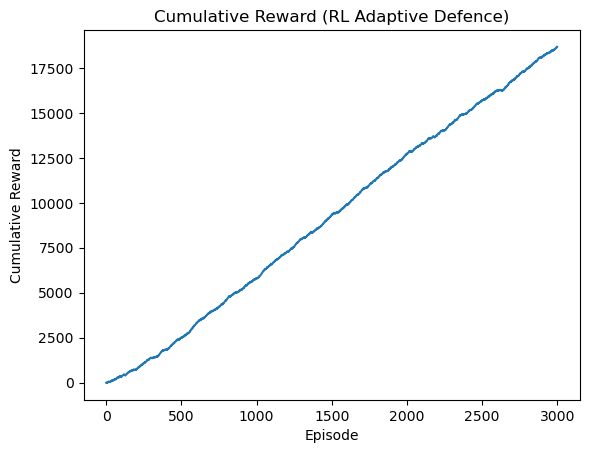

In [35]:
plt.figure()
plt.plot(total_rewards)
plt.title("Cumulative Reward (RL Adaptive Defence)")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.show()


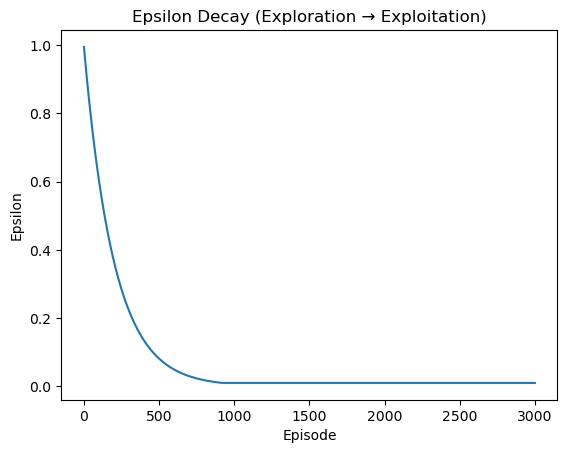

In [36]:
plt.figure()
plt.plot(epsilon_values)
plt.title("Epsilon Decay (Exploration → Exploitation)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

In [37]:
static_rewards = []

for episode in range(episodes):

    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx:idx+1]

    state = model.predict(sample)[0]
    true_label = y_test.iloc[idx]

    # Static rule: fixed response policy
    # 0 = benign → allow
    # 1 = DoS → block
    # 2 = Probe → alert
    # 3 = R2L/U2R → block

    if state == 0:
        action = 0
    elif state == 1:
        action = 1
    elif state == 2:
        action = 3
    else:
        action = 1

    reward = get_reward(true_label, action)

    if episode == 0:
        cumulative = reward
    else:
        cumulative = static_rewards[-1] + reward

    static_rewards.append(cumulative)

print("Static baseline complete.")


Static baseline complete.


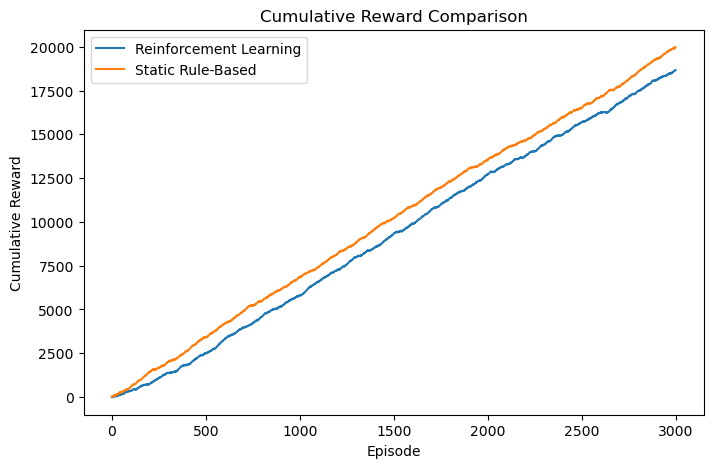

In [38]:
plt.figure(figsize=(8,5))
plt.plot(total_rewards, label="Reinforcement Learning")
plt.plot(static_rewards, label="Static Rule-Based")
plt.title("Cumulative Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.show()


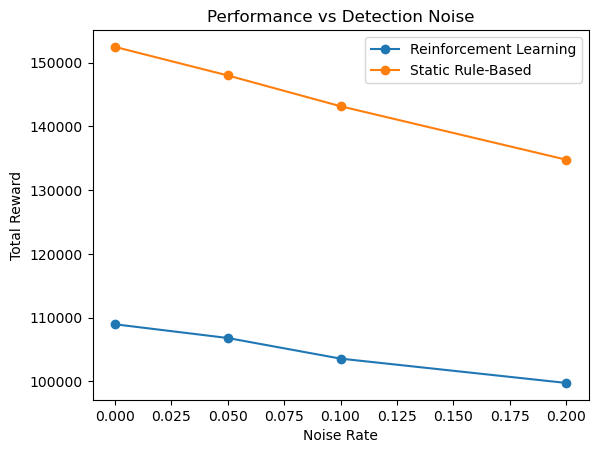

In [39]:
noise_rates = [0.0, 0.05, 0.1, 0.2]
rl_scores = []
static_scores = []

def add_noise(preds, noise_rate):
    noisy = preds.copy()
    for i in range(len(noisy)):
        if np.random.rand() < noise_rate:
            noisy[i] = np.random.randint(0, 4)
    return noisy

for nr in noise_rates:
    noisy_preds = add_noise(predictions, nr)

    # RL performance
    total = 0
    for i in range(len(noisy_preds)):
        state = noisy_preds[i]
        action = np.argmax(Q[state])
        total += get_reward(y_test.iloc[i], action)
    rl_scores.append(total)

    # Static performance
    total = 0
    for i in range(len(noisy_preds)):
        state = noisy_preds[i]
        if state == 0: action = 0
        elif state == 1: action = 1
        elif state == 2: action = 3
        else: action = 1
        total += get_reward(y_test.iloc[i], action)
    static_scores.append(total)

plt.figure()
plt.plot(noise_rates, rl_scores, marker='o', label='Reinforcement Learning')
plt.plot(noise_rates, static_scores, marker='o', label='Static Rule-Based')
plt.title("Performance vs Detection Noise")
plt.xlabel("Noise Rate")
plt.ylabel("Total Reward")
plt.legend()
plt.show()